In [331]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
  


In [332]:
# fetch dataset 
metro_traffic_volume = fetch_ucirepo(id=492) 

traffic_df = metro_traffic_volume.data.original
traffic_df


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
...,...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450


In [333]:
# First 5 rows
print("First 5 Rows:")
display(traffic_df.head())

# Last 5 rows
print("Last 5 Rows:")
display(traffic_df.tail())

# Random sample of 5 rows
print("Random sample of 5 Rows:")
display(traffic_df.sample(5, random_state=42))

First 5 Rows:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


Last 5 Rows:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450
48203,NaN,282.12,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 23:00:00,954


Random sample of 5 Rows:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
35748,NaN,289.49,0.0,0.0,1,Fog,fog,2017-07-28 07:00:00,6364
147,NaN,279.35,0.0,0.0,1,Clear,sky is clear,2012-10-08 21:00:00,2030
24362,NaN,291.39,0.0,0.0,36,Clouds,scattered clouds,2016-06-22 00:00:00,708
35495,NaN,294.02,0.0,0.0,90,Thunderstorm,thunderstorm,2017-07-19 22:00:00,2029
11010,NaN,268.69,0.0,0.0,64,Mist,mist,2013-12-27 09:00:00,3734


In [334]:
#check data types
traffic_df.dtypes

holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object

In [335]:
# Convert "date_time" column to datetime format
traffic_df["date_time"] = pd.to_datetime(traffic_df["date_time"])
traffic_df.sample(5)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
40441,NaN,274.01,0.0,0.0,20,Clouds,few clouds,2018-01-08 13:00:00,4786
36589,NaN,288.41,0.0,0.0,90,Drizzle,drizzle,2017-08-25 10:00:00,5019
34495,NaN,292.42,0.0,0.0,75,Clouds,broken clouds,2017-06-13 07:00:00,6242
15595,NaN,297.93,0.0,0.0,40,Clouds,scattered clouds,2014-07-18 14:00:00,5769
3632,NaN,270.08,0.0,0.0,90,Clouds,overcast clouds,2013-02-15 05:00:00,2364


## Inspect Timeframes

In [336]:
# check the oldest and newest timestamps
print("Oldest timestamp:", traffic_df["date_time"].min())
print("Newest timestamp:", traffic_df["date_time"].max())


Oldest timestamp: 2012-10-02 09:00:00
Newest timestamp: 2018-09-30 23:00:00


In [337]:
# calculate difference betweeen oldeste and newest timestamps
print({traffic_df['date_time'].min(), traffic_df['date_time'].max()})
print(len(traffic_df))

{Timestamp('2012-10-02 09:00:00'), Timestamp('2018-09-30 23:00:00')}
48204


In [338]:
# calculate expected number of hourly entries
len(pd.date_range(start=traffic_df['date_time'].min(), end=traffic_df['date_time'].max(), freq='h'))

52551

In [339]:
# create time skeleton to identify gaps

skeleton = pd.date_range(start = traffic_df['date_time'].min(), end = traffic_df['date_time'].max(), freq='h')
len(skeleton)

52551

In [340]:
# merging skeleton with original data to identify missing timestamps
skeleton_df = pd.DataFrame(skeleton, columns = ['date_time'])

In [341]:
df_full = pd.merge(skeleton_df, traffic_df, on = 'date_time', how = 'left')

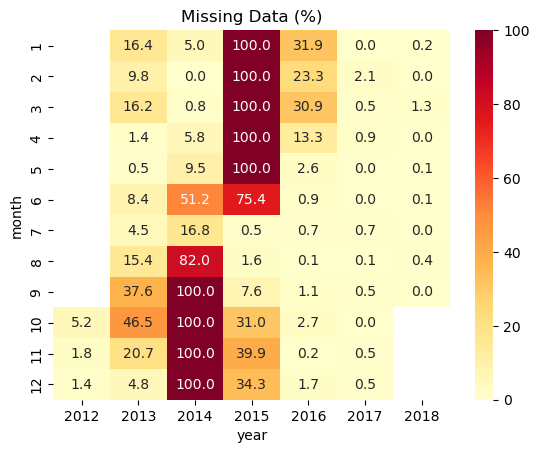

In [342]:
# Calculate fraction of missing data for each year-month
missing_heatmap_data = df_full.copy()
missing_heatmap_data['year'] = missing_heatmap_data['date_time'].dt.year
missing_heatmap_data['month'] = missing_heatmap_data['date_time'].dt.month
missing_heatmap_data['is_missing'] = missing_heatmap_data['traffic_volume'].isna()

missing_heatmap_data = (
    missing_heatmap_data
    .groupby(['year', 'month'], as_index=False)
    ['is_missing']
    .mean()
    .assign(missing_pct=lambda x: round(x['is_missing'] * 100, 1))
    [['year', 'month', 'missing_pct']]
)

sns.heatmap(missing_heatmap_data.pivot_table(index='month', columns='year', values='missing_pct'), 
            annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Missing Data (%)')
plt.show()

## Selecting 2017 as an appropriate Time Frame

In [343]:
# Filter data for the year 2017
traffic2017_df = traffic_df[traffic_df["date_time"].dt.year == 2017].copy()
traffic2017_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10605 entries, 29650 to 40254
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              12 non-null     object        
 1   temp                 10605 non-null  float64       
 2   rain_1h              10605 non-null  float64       
 3   snow_1h              10605 non-null  float64       
 4   clouds_all           10605 non-null  int64         
 5   weather_main         10605 non-null  object        
 6   weather_description  10605 non-null  object        
 7   date_time            10605 non-null  datetime64[ns]
 8   traffic_volume       10605 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 828.5+ KB


In [344]:
traffic2017_df

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
29650,NaN,269.75,0.0,0.0,75,Clouds,broken clouds,2017-01-01 00:00:00,1848
29651,NaN,269.95,0.0,0.0,1,Clear,sky is clear,2017-01-01 01:00:00,1806
29652,NaN,269.75,0.0,0.0,1,Clear,sky is clear,2017-01-01 02:00:00,1211
29653,NaN,269.65,0.0,0.0,40,Clouds,scattered clouds,2017-01-01 03:00:00,794
29654,NaN,269.48,0.0,0.0,1,Clear,sky is clear,2017-01-01 04:00:00,500
...,...,...,...,...,...,...,...,...,...
40250,NaN,249.84,0.0,0.0,1,Clear,sky is clear,2017-12-31 19:00:00,2995
40251,NaN,249.79,0.0,0.0,5,Clear,sky is clear,2017-12-31 20:00:00,2731
40252,NaN,249.61,0.0,0.0,5,Clear,sky is clear,2017-12-31 21:00:00,2483
40253,NaN,249.50,0.0,0.0,1,Clear,sky is clear,2017-12-31 22:00:00,2041


In [345]:
# drop irrelevant or empty columns
#traffic2017_df = traffic2017_df.drop(columns=["holiday"])
#traffic2017_df.info()

In [346]:
# Convert temp from Kelvin to Celsius and overwrite the column
traffic2017_df['temp'] = (traffic2017_df['temp'] - 273.15).round(2)

# Display first few rows to check
traffic2017_df[['temp']].head()



,temp
29650,-3.40
29651,-3.20
29652,-3.40
29653,-3.50
29654,-3.67


In [347]:
# Get summary statistics for numeric columns only
numeric_summary = traffic2017_df.select_dtypes(include='number').describe().round(0).astype(int)
display(numeric_summary)
print(numeric_summary.to_markdown())


,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,10605,10605,10605,10605,10605
mean,8,0,0,50,3341
std,12,0,0,40,1987
min,-27,0,0,0,186
25%,0,0,0,1,1292
50%,9,0,0,75,3530
75%,18,0,0,90,4984
max,34,0,0,92,7280


|       |   temp |   rain_1h |   snow_1h |   clouds_all |   traffic_volume |
|:------|-------:|----------:|----------:|-------------:|-----------------:|
| count |  10605 |     10605 |     10605 |        10605 |            10605 |
| mean  |      8 |         0 |         0 |           50 |             3341 |
| std   |     12 |         0 |         0 |           40 |             1987 |
| min   |    -27 |         0 |         0 |            0 |              186 |
| 25%   |      0 |         0 |         0 |            1 |             1292 |
| 50%   |      9 |         0 |         0 |           75 |             3530 |
| 75%   |     18 |         0 |         0 |           90 |             4984 |
| max   |     34 |         0 |         0 |           92 |             7280 |


In [348]:
# List of categorical columns
cat_cols = ['holiday', 'weather_main', 'weather_description']

# Print unique values for each column
for col in cat_cols:
    print(f"Unique values in '{col}':")
    print(traffic2017_df[col].unique())
    print("-" * 40)

Unique values in 'holiday':
[nan 'New Years Day' 'Martin Luther King Jr Day' 'Washingtons Birthday'
 'Memorial Day' 'Independence Day' 'State Fair' 'Labor Day' 'Columbus Day'
 'Veterans Day' 'Thanksgiving Day' 'Christmas Day']
----------------------------------------
Unique values in 'weather_main':
['Clouds' 'Clear' 'Snow' 'Mist' 'Haze' 'Rain' 'Drizzle' 'Fog'
 'Thunderstorm' 'Smoke']
----------------------------------------
Unique values in 'weather_description':
['broken clouds' 'sky is clear' 'scattered clouds' 'few clouds'
 'overcast clouds' 'light snow' 'mist' 'haze' 'light rain'
 'heavy intensity drizzle' 'drizzle' 'light intensity drizzle' 'snow'
 'fog' 'heavy snow' 'moderate rain' 'Sky is Clear' 'light rain and snow'
 'proximity shower rain' 'proximity thunderstorm' 'heavy intensity rain'
 'thunderstorm with light rain' 'proximity thunderstorm with rain'
 'thunderstorm with light drizzle' 'proximity thunderstorm with drizzle'
 'thunderstorm' 'sleet' 'light intensity shower rain

In [349]:
traffic2017_df['holiday'] = traffic2017_df['holiday'].notna().astype(int)
traffic2017_df

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
29650,0,-3.40,0.0,0.0,75,Clouds,broken clouds,2017-01-01 00:00:00,1848
29651,0,-3.20,0.0,0.0,1,Clear,sky is clear,2017-01-01 01:00:00,1806
29652,0,-3.40,0.0,0.0,1,Clear,sky is clear,2017-01-01 02:00:00,1211
29653,0,-3.50,0.0,0.0,40,Clouds,scattered clouds,2017-01-01 03:00:00,794
29654,0,-3.67,0.0,0.0,1,Clear,sky is clear,2017-01-01 04:00:00,500
...,...,...,...,...,...,...,...,...,...
40250,0,-23.31,0.0,0.0,1,Clear,sky is clear,2017-12-31 19:00:00,2995
40251,0,-23.36,0.0,0.0,5,Clear,sky is clear,2017-12-31 20:00:00,2731
40252,0,-23.54,0.0,0.0,5,Clear,sky is clear,2017-12-31 21:00:00,2483
40253,0,-23.65,0.0,0.0,1,Clear,sky is clear,2017-12-31 22:00:00,2041


In [350]:
# Map original weather_main into similar groups
weather_map = {
    'Clouds': 'Cloudy',
    'Mist': 'Cloudy',
    'Haze': 'Cloudy',
    'Fog': 'Cloudy',
    'Clear': 'Clear',
    'Rain': 'Rain',
    'Drizzle': 'Rain',
    'Snow': 'Snow',
    'Sleet': 'Snow',
    'Thunderstorm': 'Storm',
    'Smoke': 'Other'
}

traffic2017_df['weather_main'] = traffic2017_df['weather_main'].map(weather_map)

# Do One-hot encoding for weather, dropping the first column (Clear) to avoid multicollinearity
weather_dummies = pd.get_dummies(
    traffic2017_df['weather_main'], 
    prefix='weather_main', 
    drop_first=True
)

# Replace original column with encoded columns
traffic2017_df = traffic2017_df.drop('weather_main', axis=1)
traffic2017_df = pd.concat([traffic2017_df, weather_dummies], axis=1)
traffic2017_df[weather_dummies.columns] = traffic2017_df[weather_dummies.columns].astype(int)


traffic2017_df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_description,date_time,traffic_volume,weather_main_Cloudy,weather_main_Other,weather_main_Rain,weather_main_Snow,weather_main_Storm
29650,0,-3.40,0.0,0.0,75,broken clouds,2017-01-01 00:00:00,1848,1,0,0,0,0
29651,0,-3.20,0.0,0.0,1,sky is clear,2017-01-01 01:00:00,1806,0,0,0,0,0
29652,0,-3.40,0.0,0.0,1,sky is clear,2017-01-01 02:00:00,1211,0,0,0,0,0
29653,0,-3.50,0.0,0.0,40,scattered clouds,2017-01-01 03:00:00,794,1,0,0,0,0
29654,0,-3.67,0.0,0.0,1,sky is clear,2017-01-01 04:00:00,500,0,0,0,0,0


In [ ]:
# Hour of day (0-23)
traffic2017_df['hour_sin'] = np.sin(2 * np.pi * traffic2017_df['date_time'].dt.hour / 24)
traffic2017_df['hour_cos'] = np.cos(2 * np.pi * traffic2017_df['date_time'].dt.hour / 24)

# Day of week (0=Monday, 6=Sunday)
traffic2017_df['weekday_sin'] = np.sin(2 * np.pi * traffic2017_df['date_time'].dt.weekday / 7)
traffic2017_df['weekday_cos'] = np.cos(2 * np.pi * traffic2017_df['date_time'].dt.weekday / 7)

# Month of year (1-12) 
traffic2017_df['month_sin'] = np.sin(2 * np.pi * (traffic2017_df['date_time'].dt.month - 1) / 12)
traffic2017_df['month_cos'] = np.cos(2 * np.pi * (traffic2017_df['date_time'].dt.month - 1) / 12)


# Check result
traffic2017_df

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_description,date_time,traffic_volume,weather_main_Cloudy,weather_main_Other,weather_main_Rain,weather_main_Snow,weather_main_Storm,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos
29650,0,-3.40,0.0,0.0,75,broken clouds,2017-01-01 00:00:00,1848,1,0,0,0,0,0.000000,1.000000,-0.781831,0.62349,0.0,1.000000
29651,0,-3.20,0.0,0.0,1,sky is clear,2017-01-01 01:00:00,1806,0,0,0,0,0,0.258819,0.965926,-0.781831,0.62349,0.0,1.000000
29652,0,-3.40,0.0,0.0,1,sky is clear,2017-01-01 02:00:00,1211,0,0,0,0,0,0.500000,0.866025,-0.781831,0.62349,0.0,1.000000
29653,0,-3.50,0.0,0.0,40,scattered clouds,2017-01-01 03:00:00,794,1,0,0,0,0,0.707107,0.707107,-0.781831,0.62349,0.0,1.000000
29654,0,-3.67,0.0,0.0,1,sky is clear,2017-01-01 04:00:00,500,0,0,0,0,0,0.866025,0.500000,-0.781831,0.62349,0.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40250,0,-23.31,0.0,0.0,1,sky is clear,2017-12-31 19:00:00,2995,0,0,0,0,0,-0.965926,0.258819,-0.781831,0.62349,-0.5,0.866025
40251,0,-23.36,0.0,0.0,5,sky is clear,2017-12-31 20:00:00,2731,0,0,0,0,0,-0.866025,0.500000,-0.781831,0.62349,-0.5,0.866025
40252,0,-23.54,0.0,0.0,5,sky is clear,2017-12-31 21:00:00,2483,0,0,0,0,0,-0.707107,0.707107,-0.781831,0.62349,-0.5,0.866025
40253,0,-23.65,0.0,0.0,1,sky is clear,2017-12-31 22:00:00,2041,0,0,0,0,0,-0.500000,0.866025,-0.781831,0.62349,-0.5,0.866025
